In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "svg"

2.Importing the dataset

In [2]:
raw_df = pd.read_csv("tech_salary_dataset1.csv")

In [3]:
raw_df

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,company_size,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,Small (11-50),100290.66,False,0,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,Startup (1-10),92383.12,True,1,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,Enterprise (1000+),107153.59,True,4,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,Medium (51-200),217074.54,True,1,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,Startup (1-10),152246.34,False,0,6,0.0,20,3,9,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP-09996,Natasha,Silva,38,Female,"Sydney, Australia",AUD,Product Management,Associate Product Manager,Full-time,...,Large (201-1000),218700.43,True,4,3,7.3,52,2,7,False
9996,EMP-09997,Jacob,Chen,37,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,...,Small (11-50),170835.76,False,0,5,8.4,58,6,9,False
9997,EMP-09998,Kai,Muller,31,Non-Binary,"Hyderabad, India",INR,Full-Stack Development,Senior Software Engineer,Full-time,...,Startup (1-10),25695.15,True,3,4,17.1,0,0,8,False
9998,EMP-09999,Hassan,Chia,32,Male,"Boston, USA",USD,Data Science & ML,Data Scientist,Full-time,...,Enterprise (1000+),264531.10,False,0,4,14.3,78,2,6,False


3.Getting basic information about the dataset

In [4]:
raw_df.shape

(10000, 29)

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  10000 non-null  object 
 1   first_name                   10000 non-null  object 
 2   last_name                    10000 non-null  object 
 3   age                          10000 non-null  int64  
 4   gender                       10000 non-null  object 
 5   location                     10000 non-null  object 
 6   currency                     10000 non-null  object 
 7   primary_tech_field           10000 non-null  object 
 8   job_title                    10000 non-null  object 
 9   employment_type              10000 non-null  object 
 10  work_arrangement             10000 non-null  object 
 11  experience_years_total       10000 non-null  float64
 12  experience_years_in_field    10000 non-null  float64
 13  education_level  

In [6]:
raw_df['has_equity'] = raw_df['has_equity'].astype(int)
raw_df['is_actively_looking'] = raw_df['is_actively_looking'].astype(int)

In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  10000 non-null  object 
 1   first_name                   10000 non-null  object 
 2   last_name                    10000 non-null  object 
 3   age                          10000 non-null  int64  
 4   gender                       10000 non-null  object 
 5   location                     10000 non-null  object 
 6   currency                     10000 non-null  object 
 7   primary_tech_field           10000 non-null  object 
 8   job_title                    10000 non-null  object 
 9   employment_type              10000 non-null  object 
 10  work_arrangement             10000 non-null  object 
 11  experience_years_total       10000 non-null  float64
 12  experience_years_in_field    10000 non-null  float64
 13  education_level  

In [8]:
raw_df.describe()

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,31.637600,5.717070,4.019440,5.494200,171786.241744,0.499200,1.495000,3.561300,10.581700,34.515400,1.629600,6.974100,0.200600
std,6.856892,3.689415,2.823968,1.716176,72550.937998,0.500024,1.704425,1.543464,7.590467,32.959976,1.539364,2.157428,0.400469
min,18.000000,0.500000,0.500000,3.000000,19846.270000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.800000,1.800000,4.000000,121355.045000,0.000000,0.000000,2.000000,4.500000,8.000000,0.000000,6.000000,0.000000
50%,32.000000,5.500000,3.600000,5.000000,167055.180000,0.000000,0.000000,4.000000,10.100000,26.000000,1.000000,7.000000,0.000000
75%,36.000000,8.200000,5.700000,7.000000,216939.867500,1.000000,3.000000,5.000000,15.700000,52.000000,2.000000,9.000000,0.000000
max,58.000000,19.600000,17.800000,8.000000,479033.820000,1.000000,4.000000,6.000000,54.100000,224.000000,10.000000,10.000000,1.000000


4.cleaning the Dataset (a) Removing the redundant rows of data

In [9]:
# Checking the null records
raw_df.isnull().sum()

employee_id                       0
first_name                        0
last_name                         0
age                               0
gender                            0
location                          0
currency                          0
primary_tech_field                0
job_title                         0
employment_type                   0
work_arrangement                  0
experience_years_total            0
experience_years_in_field         0
education_level                   0
languages_spoken                  0
skills                            0
primary_skill                     0
num_skills                        0
certifications                 4508
company_size                      0
annual_salary_usd                 0
has_equity                        0
equity_vesting_years              0
vacation_weeks                    0
overtime_hours_per_month          0
months_since_last_promotion       0
num_previous_companies            0
job_satisfaction_score      

In [10]:
raw_df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'has_equity',
       'equity_vesting_years', 'vacation_weeks', 'overtime_hours_per_month',
       'months_since_last_promotion', 'num_previous_companies',
       'job_satisfaction_score', 'is_actively_looking'],
      dtype='object')

In [11]:
#raw_df.drop(
  #  columns=['last_name', 'primary_tech_field', 'equity_vesting_years'],
  #  inplace=True
#)

In [12]:
raw_df.fillna({"certifications": 0}, inplace=True)

In [13]:
raw_df.isnull().sum()

employee_id                    0
first_name                     0
last_name                      0
age                            0
gender                         0
location                       0
currency                       0
primary_tech_field             0
job_title                      0
employment_type                0
work_arrangement               0
experience_years_total         0
experience_years_in_field      0
education_level                0
languages_spoken               0
skills                         0
primary_skill                  0
num_skills                     0
certifications                 0
company_size                   0
annual_salary_usd              0
has_equity                     0
equity_vesting_years           0
vacation_weeks                 0
overtime_hours_per_month       0
months_since_last_promotion    0
num_previous_companies         0
job_satisfaction_score         0
is_actively_looking            0
dtype: int64

In [14]:
raw_df['company_size'].value_counts()

company_size
Enterprise (1000+)    2047
Medium (51-200)       2021
Large (201-1000)      2002
Startup (1-10)        1988
Small (11-50)         1942
Name: count, dtype: int64

In [15]:
raw_df['has_equity'].value_counts()

has_equity
0    5008
1    4992
Name: count, dtype: int64

In [16]:
raw_df[raw_df.duplicated()]

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,company_size,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking


In [17]:
def quanQual(raw_df):
    quan=[]
    qual=[]
    for columnName in raw_df.columns:
        #print(columnName)
        if(raw_df[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual

In [18]:
quan,qual=quanQual(raw_df)

In [19]:
quan

['age',
 'experience_years_total',
 'experience_years_in_field',
 'num_skills',
 'annual_salary_usd',
 'has_equity',
 'equity_vesting_years',
 'vacation_weeks',
 'overtime_hours_per_month',
 'months_since_last_promotion',
 'num_previous_companies',
 'job_satisfaction_score',
 'is_actively_looking']

In [20]:
raw_df[quan]

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,32,7.7,3.2,3,100290.66,0,0,3,12.9,38,1,6,0
1,30,3.0,1.9,8,92383.12,1,1,4,6.5,26,1,4,0
2,32,0.5,0.5,8,107153.59,1,4,5,13.2,0,0,6,1
3,31,14.5,12.4,4,217074.54,1,1,2,5.9,111,5,7,0
4,42,7.9,3.8,4,152246.34,0,0,6,0.0,20,3,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,38,6.2,3.9,6,218700.43,1,4,3,7.3,52,2,7,0
9996,37,9.7,7.0,6,170835.76,0,0,5,8.4,58,6,9,0
9997,31,0.5,0.5,5,25695.15,1,3,4,17.1,0,0,8,0
9998,32,8.7,8.3,8,264531.10,0,0,4,14.3,78,2,6,0


In [21]:
raw_df[qual]

,employee_id,first_name,last_name,gender,location,currency,primary_tech_field,job_title,employment_type,work_arrangement,education_level,languages_spoken,skills,primary_skill,certifications,company_size
0,EMP-00001,Emma,Johansson,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,Remote,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,0,Small (11-50)
1,EMP-00002,Stephanie,Zhang,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,On-site,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,0,Startup (1-10)
2,EMP-00003,Raj,Lopez,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,Remote,Bachelor's Degree,English; German; Spanish; Dutch,PHP; Express.js; Java; Rust; Spring Boot; C#; ...,PHP,AWS Certified Solutions Architect,Enterprise (1000+)
3,EMP-00004,Amelia,Taylor,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,Hybrid,Bootcamp,English; German; Mandarin,Snowflake; Elasticsearch; Cassandra; dbt,Snowflake,Linux Foundation Certified,Medium (51-200)
4,EMP-00005,Sophia,Gonzalez,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,Fully Remote,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,0,Startup (1-10)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP-09996,Natasha,Silva,Female,"Sydney, Australia",AUD,Product Management,Associate Product Manager,Full-time,Fully Remote,Bootcamp,English,Jira; Confluence; Wireframing; SQL; Agile; Roa...,Jira,0,Large (201-1000)
9996,EMP-09997,Jacob,Chen,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,On-site,Bootcamp,English,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,GraphQL,Certified Scrum Master; Azure Solutions Architect,Small (11-50)
9997,EMP-09998,Kai,Muller,Non-Binary,"Hyderabad, India",INR,Full-Stack Development,Senior Software Engineer,Full-time,Remote,Bachelor's Degree,English,TypeScript; Redis; REST APIs; PostgreSQL; Python,TypeScript,0,Startup (1-10)
9998,EMP-09999,Hassan,Chia,Male,"Boston, USA",USD,Data Science & ML,Data Scientist,Full-time,Hybrid,Bootcamp,English; Bengali,OpenCV; SQL; Keras; Python; R; PyTorch; scikit...,OpenCV,Kubernetes CKA,Enterprise (1000+)


In [22]:
qual

['employee_id',
 'first_name',
 'last_name',
 'gender',
 'location',
 'currency',
 'primary_tech_field',
 'job_title',
 'employment_type',
 'work_arrangement',
 'education_level',
 'languages_spoken',
 'skills',
 'primary_skill',
 'certifications',
 'company_size']

In [23]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(raw_df[quan])
df = imp.fit_transform(raw_df[quan])

In [24]:
df = pd.DataFrame(df,columns = quan)

In [25]:
df

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,32.0,7.7,3.2,3.0,100290.66,0.0,0.0,3.0,12.9,38.0,1.0,6.0,0.0
1,30.0,3.0,1.9,8.0,92383.12,1.0,1.0,4.0,6.5,26.0,1.0,4.0,0.0
2,32.0,0.5,0.5,8.0,107153.59,1.0,4.0,5.0,13.2,0.0,0.0,6.0,1.0
3,31.0,14.5,12.4,4.0,217074.54,1.0,1.0,2.0,5.9,111.0,5.0,7.0,0.0
4,42.0,7.9,3.8,4.0,152246.34,0.0,0.0,6.0,0.0,20.0,3.0,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,38.0,6.2,3.9,6.0,218700.43,1.0,4.0,3.0,7.3,52.0,2.0,7.0,0.0
9996,37.0,9.7,7.0,6.0,170835.76,0.0,0.0,5.0,8.4,58.0,6.0,9.0,0.0
9997,31.0,0.5,0.5,5.0,25695.15,1.0,3.0,4.0,17.1,0.0,0.0,8.0,0.0
9998,32.0,8.7,8.3,8.0,264531.10,0.0,0.0,4.0,14.3,78.0,2.0,6.0,0.0


In [26]:
raw_df.isna().sum()

employee_id                    0
first_name                     0
last_name                      0
age                            0
gender                         0
location                       0
currency                       0
primary_tech_field             0
job_title                      0
employment_type                0
work_arrangement               0
experience_years_total         0
experience_years_in_field      0
education_level                0
languages_spoken               0
skills                         0
primary_skill                  0
num_skills                     0
certifications                 0
company_size                   0
annual_salary_usd              0
has_equity                     0
equity_vesting_years           0
vacation_weeks                 0
overtime_hours_per_month       0
months_since_last_promotion    0
num_previous_companies         0
job_satisfaction_score         0
is_actively_looking            0
dtype: int64

In [27]:
from sklearn.impute import SimpleImputer
imp_cat = SimpleImputer(strategy="most_frequent")
cate=raw_df[qual]
cate = imp_cat.fit_transform(raw_df[qual])

In [28]:
cate = pd.DataFrame(cate,columns = qual)

In [29]:
cate

,employee_id,first_name,last_name,gender,location,currency,primary_tech_field,job_title,employment_type,work_arrangement,education_level,languages_spoken,skills,primary_skill,certifications,company_size
0,EMP-00001,Emma,Johansson,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,Remote,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,0,Small (11-50)
1,EMP-00002,Stephanie,Zhang,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,On-site,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,0,Startup (1-10)
2,EMP-00003,Raj,Lopez,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,Remote,Bachelor's Degree,English; German; Spanish; Dutch,PHP; Express.js; Java; Rust; Spring Boot; C#; ...,PHP,AWS Certified Solutions Architect,Enterprise (1000+)
3,EMP-00004,Amelia,Taylor,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,Hybrid,Bootcamp,English; German; Mandarin,Snowflake; Elasticsearch; Cassandra; dbt,Snowflake,Linux Foundation Certified,Medium (51-200)
4,EMP-00005,Sophia,Gonzalez,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,Fully Remote,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,0,Startup (1-10)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP-09996,Natasha,Silva,Female,"Sydney, Australia",AUD,Product Management,Associate Product Manager,Full-time,Fully Remote,Bootcamp,English,Jira; Confluence; Wireframing; SQL; Agile; Roa...,Jira,0,Large (201-1000)
9996,EMP-09997,Jacob,Chen,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,On-site,Bootcamp,English,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,GraphQL,Certified Scrum Master; Azure Solutions Architect,Small (11-50)
9997,EMP-09998,Kai,Muller,Non-Binary,"Hyderabad, India",INR,Full-Stack Development,Senior Software Engineer,Full-time,Remote,Bachelor's Degree,English,TypeScript; Redis; REST APIs; PostgreSQL; Python,TypeScript,0,Startup (1-10)
9998,EMP-09999,Hassan,Chia,Male,"Boston, USA",USD,Data Science & ML,Data Scientist,Full-time,Hybrid,Bootcamp,English; Bengali,OpenCV; SQL; Keras; Python; R; PyTorch; scikit...,OpenCV,Kubernetes CKA,Enterprise (1000+)


In [30]:
two=[df,cate]

In [31]:
preprocessed=pd.concat(two,axis=1)

In [32]:
preprocessed

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,...,primary_tech_field,job_title,employment_type,work_arrangement,education_level,languages_spoken,skills,primary_skill,certifications,company_size
0,32.0,7.7,3.2,3.0,100290.66,0.0,0.0,3.0,12.9,38.0,...,Backend Development,Platform Engineer,Full-time,Remote,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,0,Small (11-50)
1,30.0,3.0,1.9,8.0,92383.12,1.0,1.0,4.0,6.5,26.0,...,QA & Testing,QA Engineer,Full-time,On-site,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,0,Startup (1-10)
2,32.0,0.5,0.5,8.0,107153.59,1.0,4.0,5.0,13.2,0.0,...,Backend Development,API Engineer,Full-time,Remote,Bachelor's Degree,English; German; Spanish; Dutch,PHP; Express.js; Java; Rust; Spring Boot; C#; ...,PHP,AWS Certified Solutions Architect,Enterprise (1000+)
3,31.0,14.5,12.4,4.0,217074.54,1.0,1.0,2.0,5.9,111.0,...,Database & Data Engineering,Analytics Engineer,Full-time,Hybrid,Bootcamp,English; German; Mandarin,Snowflake; Elasticsearch; Cassandra; dbt,Snowflake,Linux Foundation Certified,Medium (51-200)
4,42.0,7.9,3.8,4.0,152246.34,0.0,0.0,6.0,0.0,20.0,...,Embedded Systems & IoT,Embedded Engineer,Full-time,Fully Remote,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,0,Startup (1-10)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,38.0,6.2,3.9,6.0,218700.43,1.0,4.0,3.0,7.3,52.0,...,Product Management,Associate Product Manager,Full-time,Fully Remote,Bootcamp,English,Jira; Confluence; Wireframing; SQL; Agile; Roa...,Jira,0,Large (201-1000)
9996,37.0,9.7,7.0,6.0,170835.76,0.0,0.0,5.0,8.4,58.0,...,Full-Stack Development,Full Stack Developer,Full-time,On-site,Bootcamp,English,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,GraphQL,Certified Scrum Master; Azure Solutions Architect,Small (11-50)
9997,31.0,0.5,0.5,5.0,25695.15,1.0,3.0,4.0,17.1,0.0,...,Full-Stack Development,Senior Software Engineer,Full-time,Remote,Bachelor's Degree,English,TypeScript; Redis; REST APIs; PostgreSQL; Python,TypeScript,0,Startup (1-10)
9998,32.0,8.7,8.3,8.0,264531.10,0.0,0.0,4.0,14.3,78.0,...,Data Science & ML,Data Scientist,Full-time,Hybrid,Bootcamp,English; Bengali,OpenCV; SQL; Keras; Python; R; PyTorch; scikit...,OpenCV,Kubernetes CKA,Enterprise (1000+)


In [33]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [34]:
def Bivariate(preprocessed,quan):
        descriptive=pd.DataFrame(index=["Mean","Median","Mode","25%","50%","75%","99%","100%","IQR","1.5rule","Lesser","Greater","Min","Max","Skew","Kurtosis","Var","SD"],columns=quan)
        for columnName in quan:
            descriptive[columnName]["Mean"]=preprocessed[columnName].mean()
            descriptive[columnName]["Median"]=preprocessed[columnName].median()
            descriptive[columnName]["Mode"]=preprocessed[columnName].mode()[0]
            descriptive[columnName]["25%"]=preprocessed.describe()[columnName]["25%"]
            descriptive[columnName]["50%"]=preprocessed.describe()[columnName]["50%"]
            descriptive[columnName]["75%"]=preprocessed.describe()[columnName]["75%"]
            descriptive[columnName]["99%"]=np.percentile(preprocessed[columnName],99)
            descriptive[columnName]["100%"]=preprocessed.describe()[columnName]["max"]
            descriptive[columnName]["IQR"]=descriptive[columnName]["75%"]-descriptive[columnName]["25%"]
            descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
            descriptive[columnName]["Lesser"]=descriptive[columnName]["25%"]-descriptive[columnName]["1.5rule"]
            descriptive[columnName]["Greater"]=descriptive[columnName]["75%"]+descriptive[columnName]["1.5rule"]
            descriptive[columnName]["Min"]=preprocessed[columnName].min()
            descriptive[columnName]["Max"]=preprocessed[columnName].max()
            descriptive[columnName]["Skew"]=preprocessed[columnName].skew()
            descriptive[columnName]["Kurtosis"]=preprocessed[columnName].kurtosis()
            descriptive[columnName]["Var"]=preprocessed[columnName].var()
            descriptive[columnName]["SD"]=preprocessed[columnName].std()
        return descriptive   

In [35]:
 Bivariate(preprocessed,quan)

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,has_equity,equity_vesting_years,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
Mean,31.6376,5.71707,4.01944,5.4942,171786.241744,0.4992,1.495,3.5613,10.5817,34.5154,1.6296,6.9741,0.2006
Median,32.0,5.5,3.6,5.0,167055.18,0.0,0.0,4.0,10.1,26.0,1.0,7.0,0.0
Mode,33.0,0.5,0.5,4.0,198390.48,0.0,0.0,4.0,0.0,0.0,1.0,7.0,0.0
25%,27.0,2.8,1.8,4.0,121355.045,0.0,0.0,2.0,4.5,8.0,0.0,6.0,0.0
50%,32.0,5.5,3.6,5.0,167055.18,0.0,0.0,4.0,10.1,26.0,1.0,7.0,0.0
75%,36.0,8.2,5.7,7.0,216939.8675,1.0,3.0,5.0,15.7,52.0,2.0,9.0,0.0
99%,48.0,15.2,12.101,8.0,365745.6973,1.0,4.0,6.0,29.9,136.0,6.0,10.0,1.0
100%,58.0,19.6,17.8,8.0,479033.82,1.0,4.0,6.0,54.1,224.0,10.0,10.0,1.0
IQR,9.0,5.4,3.9,3.0,95584.8225,1.0,3.0,3.0,11.2,44.0,2.0,3.0,0.0
1.5rule,13.5,8.1,5.85,4.5,143377.23375,1.5,4.5,4.5,16.8,66.0,3.0,4.5,0.0


In [36]:
import seaborn as sns

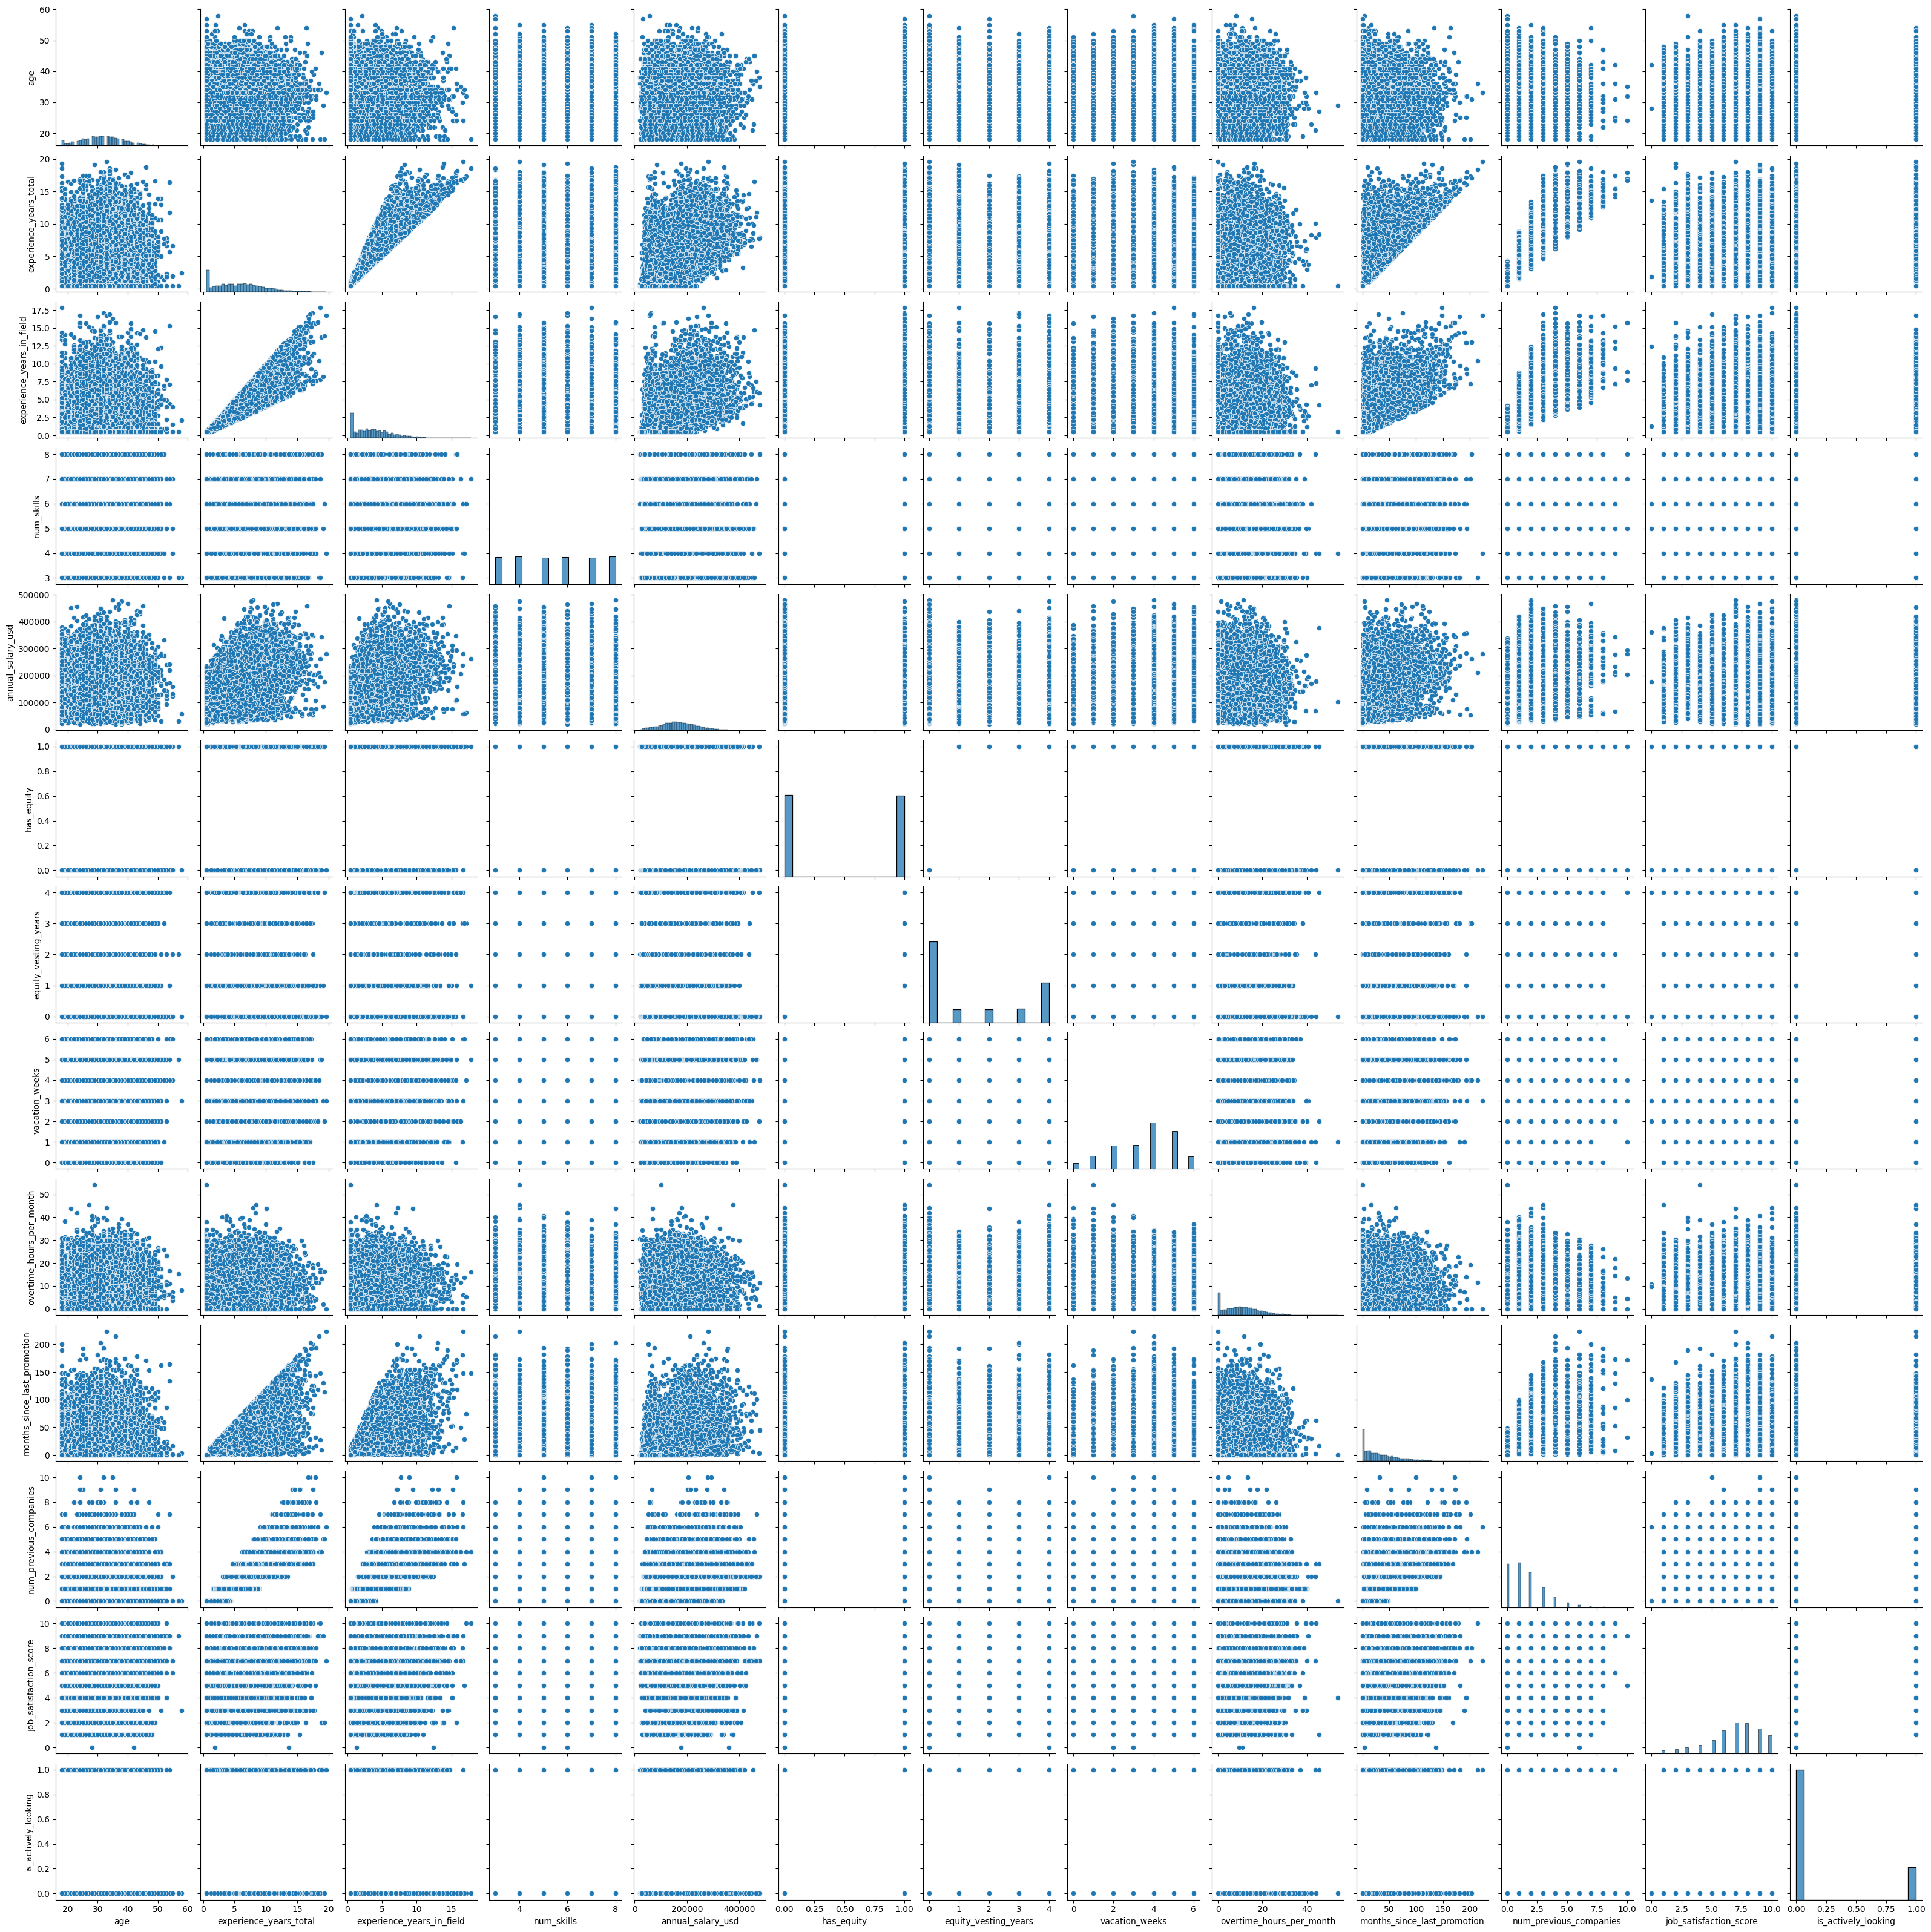

In [37]:
sns.pairplot(preprocessed)

<Axes: xlabel='job_satisfaction_score', ylabel='Density'>

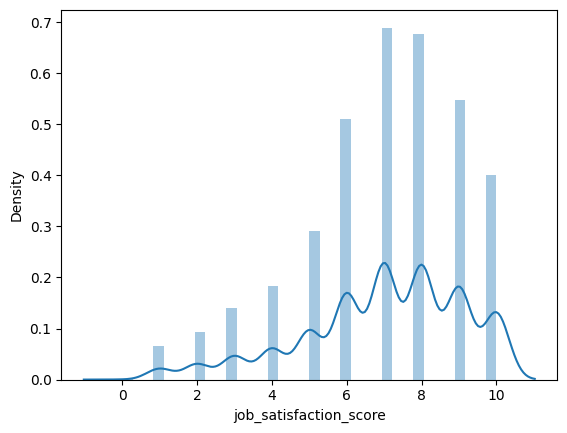

In [39]:
sns.distplot(preprocessed["job_satisfaction_score"])

In [40]:
import matplotlib.pyplot as plt

In [41]:
numerical_features = [
    "months_since_last_promotion",
    "overtime_hours_per_month",
    "annual_salary_usd",
    "experience_years_in_field",
    "job_satisfaction_score"
]
target = "is_actively_looking"
preprocessed[target] = preprocessed[target].astype(str)


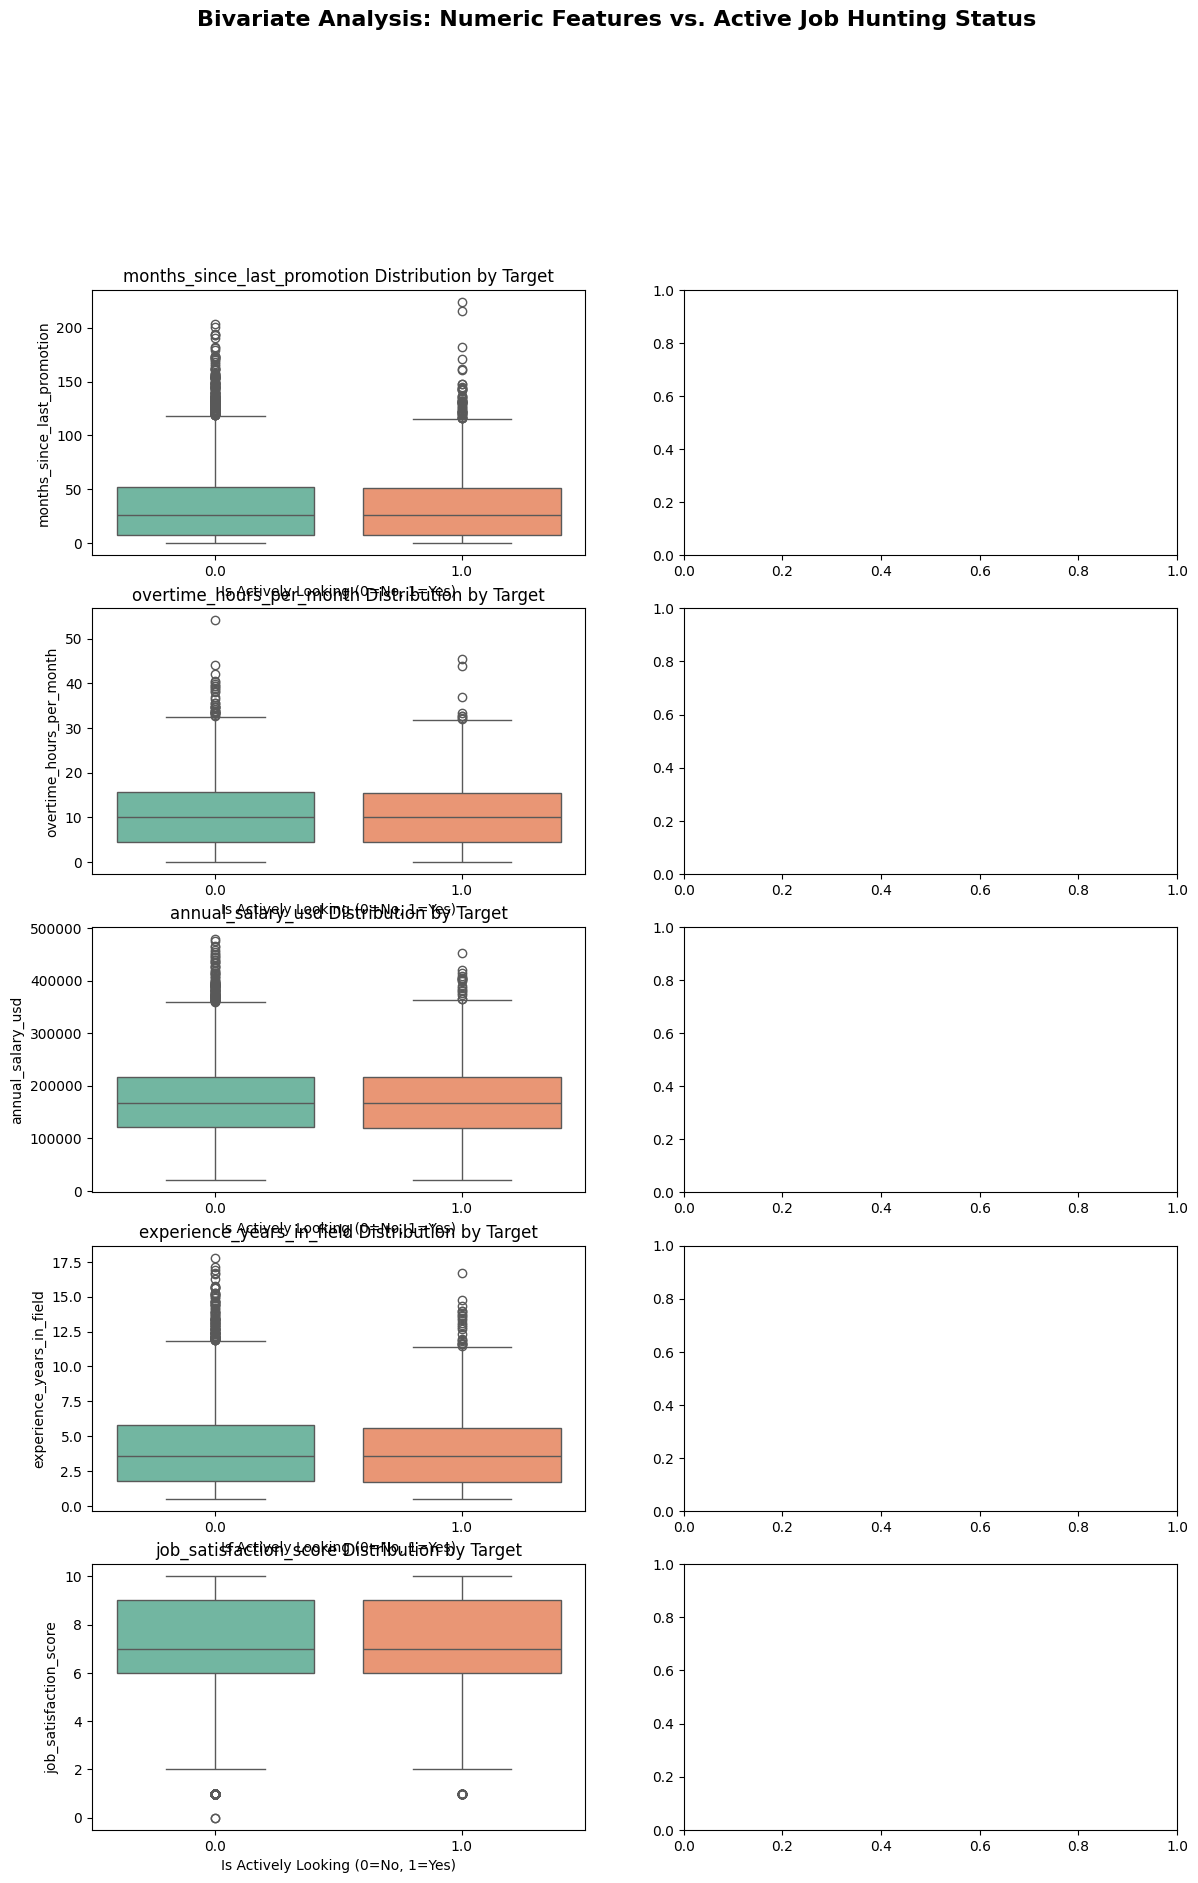

In [42]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(14, 4 * len(numerical_features)))
fig.suptitle("Bivariate Analysis: Numeric Features vs. Active Job Hunting Status", fontsize=16, weight='bold', y=1.02)
for i, col in enumerate(numerical_features):
    # Plot 1: Box Plot (Shows median shifts, IQRs, and extreme outliers side-by-side)
    sns.boxplot(
        data=preprocessed, 
        x=target, 
        y=col, 
        ax=axes[i, 0], 
        palette="Set2",
        hue=target,
        legend=False
    )
    axes[i, 0].set_title(f"{col} Distribution by Target", fontsize=12)
    axes[i, 0].set_xlabel("Is Actively Looking (0=No, 1=Yes)")

In [45]:
sns.kdeplot(
        data=preprocessed, 
        x=col, 
        hue=target, 
        fill=True, 
        common_norm=False, 
        ax=axes[i, 1], 
        palette="Set2", 
        alpha=0.5
    )
axes[i, 1].set_title(f"{col} Density Distribution", fontsize=12)
axes[i, 1].set_xlabel(col)

# Clean up layout overlap
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [46]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

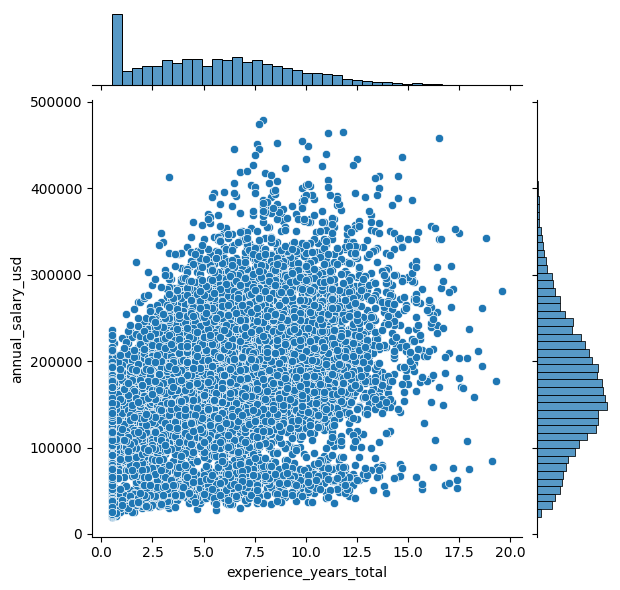

In [48]:
import seaborn as sb
sb.jointplot(x = 'experience_years_total',y = 'annual_salary_usd',data = preprocessed)
plt.show()

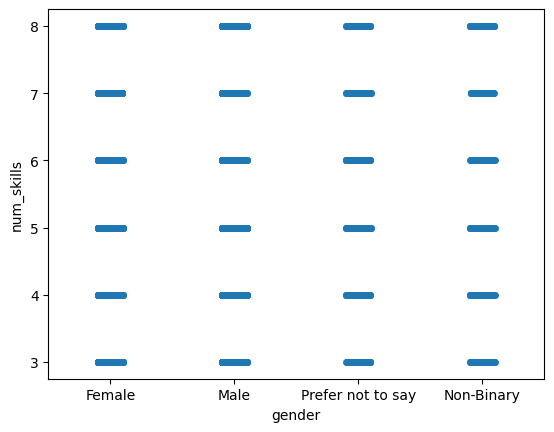

In [51]:
# plot between categorical & quantitative data
sb.stripplot(x = "gender", y = "num_skills", data = preprocessed)
plt.show()

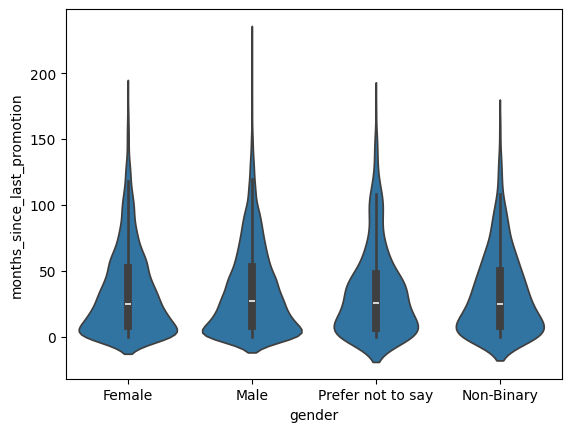

In [52]:
sb.violinplot(x = "gender", y = "months_since_last_promotion", data = preprocessed)
plt.show()

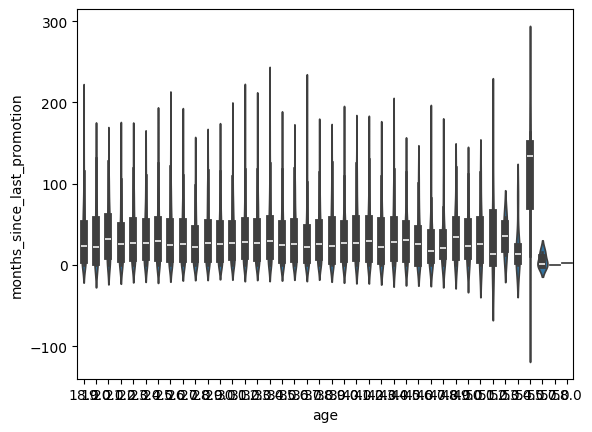

In [53]:
sb.violinplot(x = "age", y = "months_since_last_promotion", data = preprocessed)
plt.show()

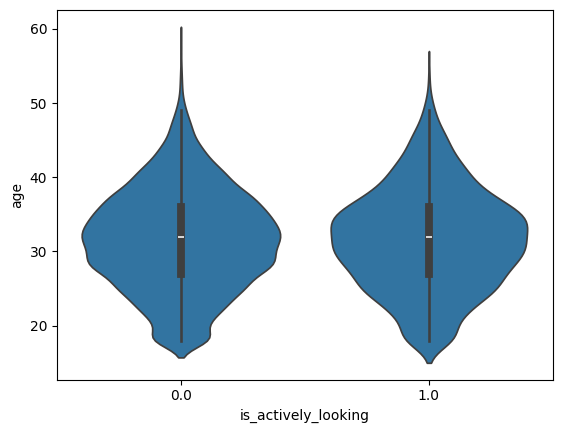

In [55]:
sb.violinplot(x = "is_actively_looking", y = "age", data = preprocessed)
plt.show()

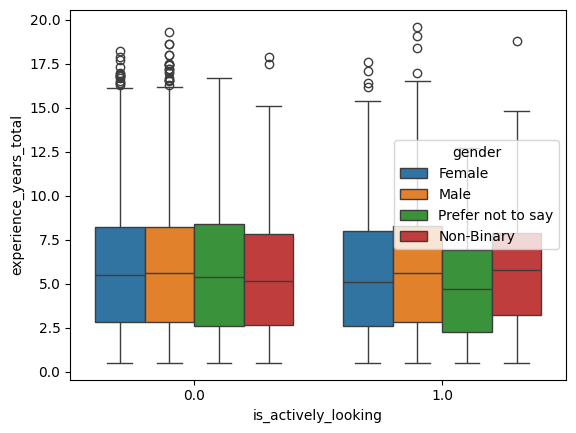

In [57]:
sb.boxplot(x = "is_actively_looking", y = "experience_years_total", data =preprocessed,hue="gender" )
plt.show()

In [58]:
preprocessed.to_csv('final_data.csv', index=False)